# VGG16 and DenseNet201 — 10 epochs

Training and evaluation of VGG16 and DenseNet201 transfer-learning models for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Train size: 4900, Validation size: 1050, Test size: 1050
Found 4900 validated image filenames.
Found 1050 validated image filenames.
Found 1050 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 1830s 12s/step - accuracy: 0.8325 - loss: 0.3220 - val_accuracy: 0.9762 - val_loss: 0.0622
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1790s 12s/step - accuracy: 0.9611 - loss: 0.1050 - val_accuracy: 0.9810 - val_loss: 0.0723
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1825s 12s/step - accuracy: 0.9702 - loss: 0.0804 - val_accuracy: 0.9838 - val_loss: 0.0530
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1962s 13s/step - accuracy: 0.9774 - loss: 0.0525 - val_accuracy: 0.9876 - val_loss: 0.0428
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1869s 12s/step - accuracy: 0.9873 - loss: 0.0430 - val_accuracy: 0.9905 - val_loss: 0.0258
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1803s 12s/step - accuracy: 0.9871 - loss: 0.0384 - val_accuracy: 0.9867 - val_loss: 0.0473
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1815s 12s/step - accuracy: 0.9876 - loss: 0.0384 - val_accuracy: 0.9914 - val_loss: 0.0335
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1811s 12s/step - accuracy: 0.9876 - loss: 0.0391 - val

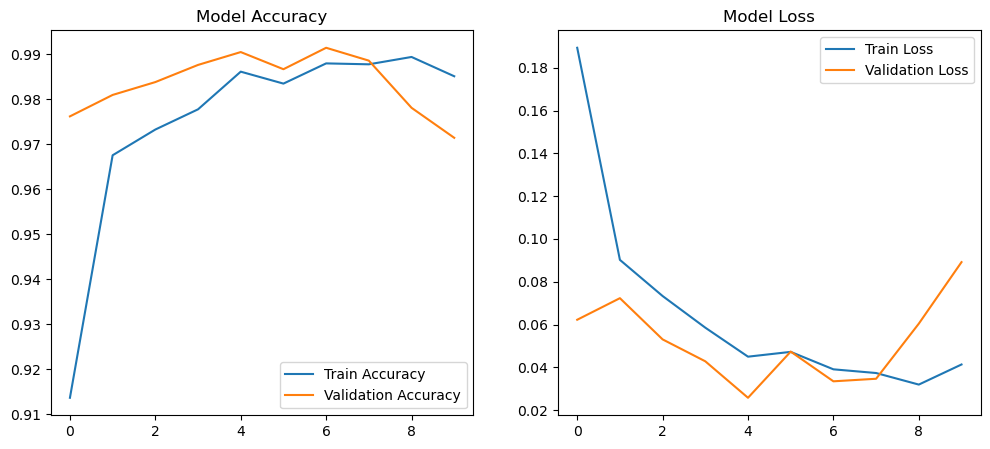

33/33 ━━━━━━━━━━━━━━━━━━━━ 291s 9s/step - accuracy: 0.9698 - loss: 0.0991
Test Accuracy: 97.14%
Test Loss: 0.0934
33/33 ━━━━━━━━━━━━━━━━━━━━ 296s 9s/step


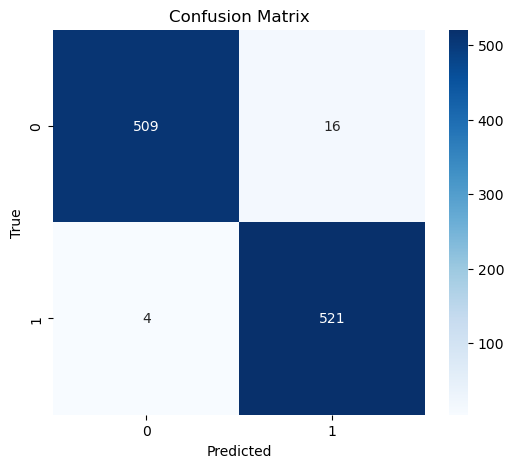


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       525
          TB       0.97      0.99      0.98       525

    accuracy                           0.98      1050
   macro avg       0.98      0.98      0.98      1050
weighted avg       0.98      0.98      0.98      1050



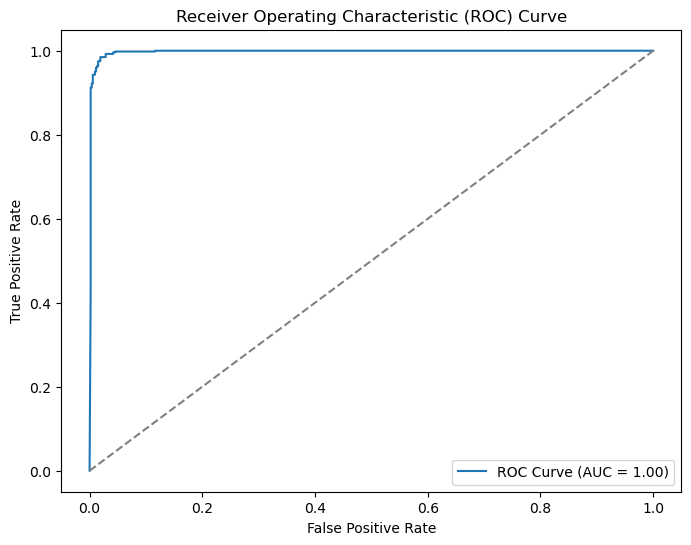

In [ ]:
### 10 Epochs VGG16

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

base_path = r'data/TB_Chest_Radiography_Database'

image_paths = []
labels = []

categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})  

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


for layer in base_model.layers[:-4]:  
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, validation_data=val_generator, epochs=10)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")  

y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [6]:
from tensorflow.keras.models import load_model
model = load_model('tb_vgg16_model.keras')


In [ ]:
#10 Epochs DenseNet201

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[:-4]:  
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, validation_data=val_generator, epochs=10)

model.save("tb_densenet201_model.h5") 


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step
Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1463s 9s/step - accuracy: 0.7679 - loss: 0.4722 - val_accuracy: 0.9600 - val_loss: 0.1326
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1520s 10s/step - accuracy: 0.9365 - loss: 0.1662 - val_accuracy: 0.9571 - val_loss: 0.1182
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1483s 10s/step - accuracy: 0.9470 - loss: 0.1415 - val_accuracy: 0.9629 - val_loss: 0.0859
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1726s 11s/step - accuracy: 0.9473 - loss: 0.1289 - val_accuracy: 0.9781 - val_loss: 0.0586
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1667s 11s/step - accuracy: 0.9587 - loss: 0.1014 - val_accuracy: 0.9733 - val_loss: 0.0687
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1727s 11s/step - accuracy: 0.9568 - loss: 0.1126 - val_accuracy: 0.9829 - val_loss: 0.0603
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1732s 11s/step - accuracy: 0.9608 - loss: 0.0973 - val_accuracy: 0.9790 - val_loss: 0.0631
Epoch 8/10
154/154 ━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("tb_densenet201_model.h5")

In [ ]:
# Extract true labels from test_generator
y_true = test_generator.labels  


33/33 ━━━━━━━━━━━━━━━━━━━━ 287s 9s/step


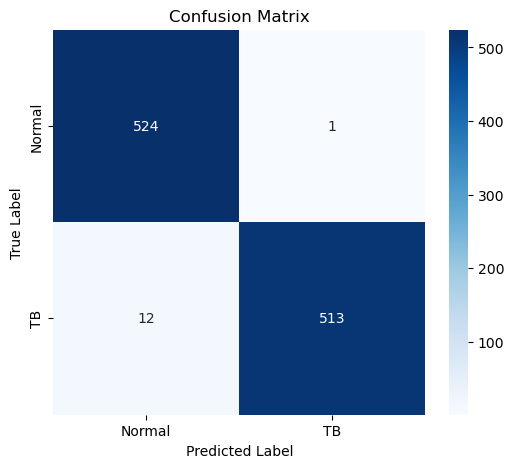

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       525
          TB       1.00      0.98      0.99       525

    accuracy                           0.99      1050
   macro avg       0.99      0.99      0.99      1050
weighted avg       0.99      0.99      0.99      1050



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

## Get true labels
y_true = test_generator.labels 

# Predict class probabilities
y_pred_prob = model.predict(test_generator)

# Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal', 'TB'], yticklabels=['Normal', 'TB'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))


In [ ]:
# Evaluate the model on the test set

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 168s 5s/step - accuracy: 0.9895 - loss: 0.0306
Test Accuracy: 0.9895
Test Loss: 0.0381


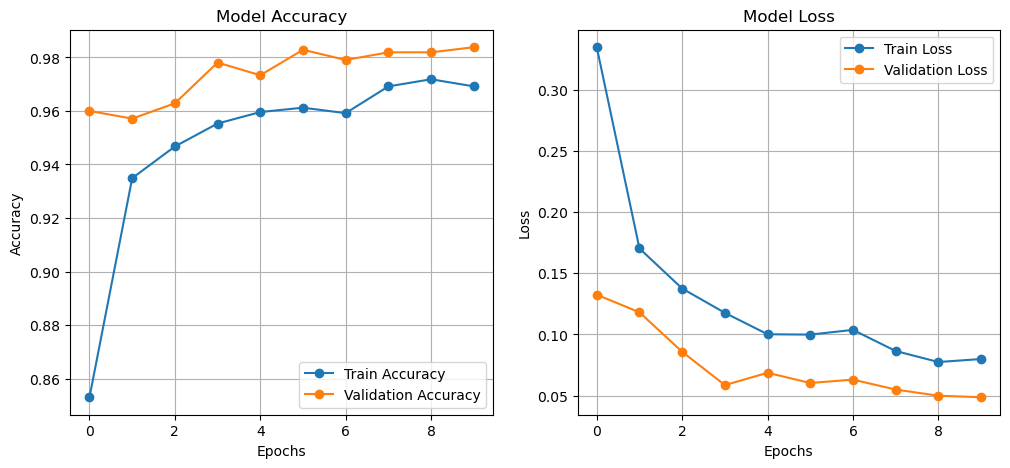

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()

plt.show()


In [ ]:
# Confusion matrix values from your model
tn, fp, fn, tp = 524, 1, 12, 513

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall for TB): {sensitivity:.4f}")
print(f"Specificity (Recall for Normal): {specificity:.4f}")


Sensitivity (Recall for TB): 0.9771
Specificity (Recall for Normal): 0.9981


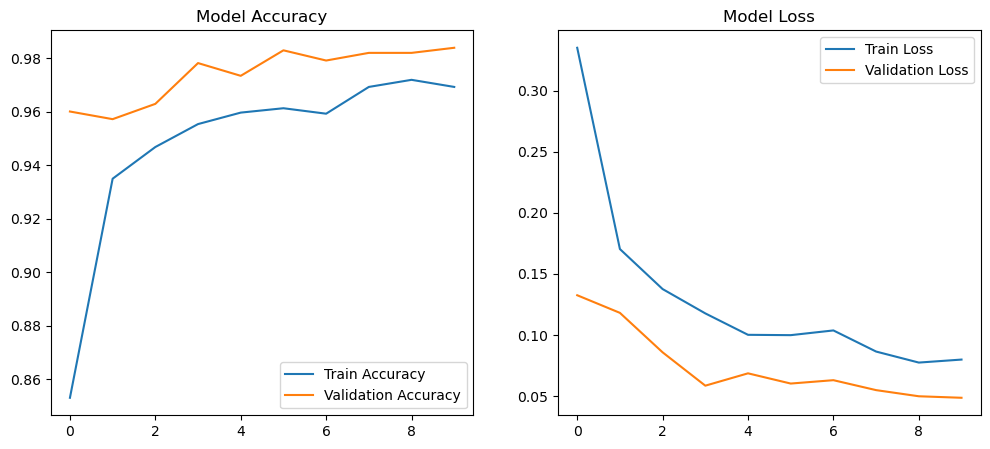

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 162s 5s/step


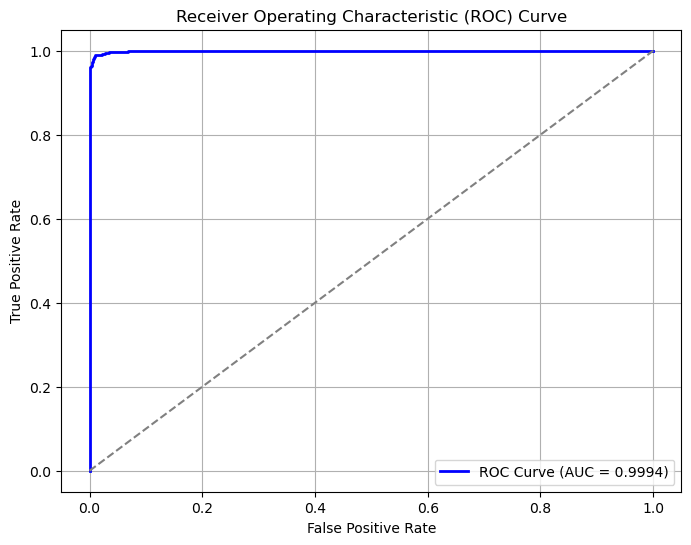

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


y_true = test_generator.labels 


y_pred_probs = model.predict(test_generator) 

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


In [49]:
pip install fastapi uvicorn tensorflow numpy pillow python-multipart


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
import nest_asyncio
nest_asyncio.apply()


In [ ]:
import numpy as np
import tensorflow as tf
from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from fastapi.responses import JSONResponse
import uvicorn
from io import BytesIO
from PIL import Image

app = FastAPI(title="TB Classification API", description="Upload a chest X-ray image to detect tuberculosis.", version="1.0")

MODEL_PATH = "tb_densenet201_model.h5"
model = load_model(MODEL_PATH)

def preprocess_image(image_data):
    img = Image.open(BytesIO(image_data))  
    img = img.resize((224, 224))  
    img_array = np.array(img) / 255.0  
    img_array = np.expand_dims(img_array, axis=0) 
    return img_array

@app.get("/")
def home():
    return {"message": "Welcome to the TB Classification API!"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    try:
        image_data = await file.read()
        img_array = preprocess_image(image_data)

        prediction = model.predict(img_array)
        result = "TB Detected" if prediction[0][0] > 0.5 else "Normal"

        return JSONResponse(content={"diagnosis": result, "confidence": float(prediction[0][0])})

    except Exception as e:
        return JSONResponse(content={"error": str(e)}, status_code=500)

# Run API with Uvicorn

if __name__ == "__main__":
    import nest_asyncio
    nest_asyncio.apply()
    uvicorn.run(app, host="0.0.0.0", port=8005)


INFO:     Started server process [6968]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8005 (Press CTRL+C to quit)


INFO:     127.0.0.1:50771 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:50771 - "GET /openapi.json HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
INFO:     127.0.0.1:50776 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
INFO:     127.0.0.1:50782 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
INFO:     127.0.0.1:50785 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
INFO:     127.0.0.1:50790 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
INFO:     127.0.0.1:50794 - "POST /predict HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [6968]


In [ ]:
model = tf.keras.models.load_model("tb_densenet201_model.h5", compile=False)
model.compile() 


In [63]:
def compute_gradcam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,  # Use model's actual input
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, tf.argmax(predictions[0])]


In [ ]:
for layer in model.layers:
    print(layer.name)

densenet201
global_average_pooling2d
dense_6
dropout_4
dense_7
dropout_5
dense_8
